# 作業1：Word Analogy with Word Embeddings

## Part I: Data Pre-processing

In [1]:
# 0. 引入套件

import pandas as pd

In [2]:
# 1. 下載 Google Analogy 資料集

!wget http://download.tensorflow.org/data/questions-words.txt

--2026-03-18 15:21:55--  http://download.tensorflow.org/data/questions-words.txt
Resolving download.tensorflow.org (download.tensorflow.org)... 64.233.181.207, 142.250.125.207, 142.250.152.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|64.233.181.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: ‘questions-words.txt’

questions-words.txt 100%[===================>] 589.80K  --.-KB/s    in 0.03s   

2026-03-18 15:21:55 (17.7 MB/s) - ‘questions-words.txt’ saved [603955/603955]



In [3]:
# 2. 讀入資料集，使其變成 list 的形式

file_name = "questions-words"
with open(f"{file_name}.txt", "r") as f:
    data = f.read().splitlines() # 將每一行的資料分割成 list 的元素

In [4]:
# 3. 印出前 10 筆資料，確認資料集的內容

for entry in data[:10]:
    print(entry)

: capital-common-countries
Athens Greece Baghdad Iraq
Athens Greece Bangkok Thailand
Athens Greece Beijing China
Athens Greece Berlin Germany
Athens Greece Bern Switzerland
Athens Greece Cairo Egypt
Athens Greece Canberra Australia
Athens Greece Hanoi Vietnam
Athens Greece Havana Cuba


In [5]:
# 4. TODO1: 將資料處理成 pd.DataFrame 的形式
# 請將資料 (`questions-words.txt`) 處理成 pd.DataFrame
# 請注意，`questions-words.txt` 中前五次出現的 ": " 表示 `semantic` 類別 (語義相似性)，
# 而其餘九次則屬於 `syntatic` 類別 (語法相似性)。
# 請參考第5格來處理資料，並將結果存成 `df` 變數。

questions, categories, sub_categories = [], [], []

category_count = 0
current_category = ""
current_sub_category = ""

for entry in data:
    if entry.startswith(": "):
        category_count += 1
        current_sub_category = entry
        if category_count <= 5: # The first 5 are semantic
            current_category = "semantic"
        else : # The next 9 are syntactic
            current_category = "syntactic"
    else:
        # This is a question entry
        questions.append(entry)
        categories.append(current_category)
        sub_categories.append(current_sub_category)

# Create the dataframe
df = pd.DataFrame(
    {
        "Question": questions,
        "Category": categories,
        "SubCategory": sub_categories,
    }
)

In [6]:
# 5. Create the dataframe
# 其中 questions, categories, sub_categories 皆為 list 的形式

df = pd.DataFrame(
    {
        "Question": questions,
        "Category": categories,
        "SubCategory": sub_categories,
    }
)

In [7]:
# 6. 你可以觀察一下資料集的前幾筆資料，確認是否正確處理

df.head()

# 將資料存成 csv 檔案
df.to_csv(f"{file_name}.csv", index=False)

## Part II: Use pre-trained word embeddings
- After finish Part I, you can run Part II code blocks only.

In [8]:
# 0. 引入套件

!pip install gensim
import pandas as pd
import numpy as np
import gensim.downloader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.8 MB/s eta 0:00:00


In [9]:
# 7. 讀入剛剛處理好的 csv 檔案

data = pd.read_csv("questions-words.csv")

In [10]:
# 8. 載入預訓練好的詞向量模型 (pre-trained word embeddings)

MODEL_NAME = "glove-wiki-gigaword-100"
# You can try other models.
# https://radimrehurek.com/gensim/models/word2vec.html#pretrained-models

# Load the pre-trained model (using GloVe vectors here)
model = gensim.downloader.load(MODEL_NAME)
print("The Gensim model loaded successfully!")

[==================================================] 100.0% 128.1/128.1MB downloaded
The Gensim model loaded successfully!


In [ ]:
# 9. TODO2: 進行 word analogy 預測，並保留 gold answers (word_D)

# Do predictions and preserve the gold answers (word_D)
preds = []
golds = [] # 因為等等要對答案進行評估，所以我們需要保留 gold answers (word_D)

for analogy in tqdm(data["Question"]):
      # Use pre-trained word embeddings for getting predictions of the analogy task.
      # You should also preserve the gold answers during iterations for evaluations later.
      #Hints
      # Unpack the analogy (e.g., "man", "woman", "king", "queen")
      # Perform vector arithmetic: word_b + word_c - word_a should be close to word_d
      # Source: https://github.com/piskvorky/gensim/blob/develop/gensim/models/keyedvectors.py#L778
      # Mikolov et al., 2013: big - biggest and small - smallest
      # Mikolov et al., 2013: X = vector(”biggest”) − vector(”big”) + vector(”small”).

      # Write your code here


    word_a, word_b, word_c, word_d = analogy.lower().split()

    # 保留 gold的答案
    golds.append(word_d)

    try:
        # 向量運算
        resu = model.most_similar(
            positive=[word_b, word_c],
            negative=[word_a],
            topn=1
        )
        preds.append(resu[0][0])
    except KeyError:
        # 若詞不在詞彙表中，填入空字串
        preds.append("")

100%|██████████| 19544/19544 [06:55<00:00, 47.03it/s]


In [12]:
# 10. 進行模型評估，此格不需要修改

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: semantic, Accuracy: 65.3399481339497%
Category: syntactic, Accuracy: 61.255269320843084%
Sub-Category: capital-common-countries, Accuracy: 93.87351778656127%
Sub-Category: capital-world, Accuracy: 88.94783377541998%
Sub-Category: currency, Accuracy: 14.203233256351039%
Sub-Category: city-in-state, Accuracy: 30.806647750304013%
Sub-Category: family, Accuracy: 81.62055335968378%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 24.39516129032258%
Sub-Category: gram2-opposite, Accuracy: 20.073891625615765%
Sub-Category: gram3-comparative, Accuracy: 79.12912912912913%
Sub-Category: gram4-superlative, Accuracy: 54.278074866310156%
Sub-Category: gram5-present-participle, Accuracy: 69.50757575757575%
Sub-Category: gram6-nationality-adjective, Accuracy: 87.86741713570981%
Sub-Category: gram7-past-tense, Accuracy: 55.44871794871795%
Sub-Category: gram8-plural, Accuracy: 71.996996996997%
Sub-Category: gram9-plural-verbs, Accuracy: 58.39080459770115%


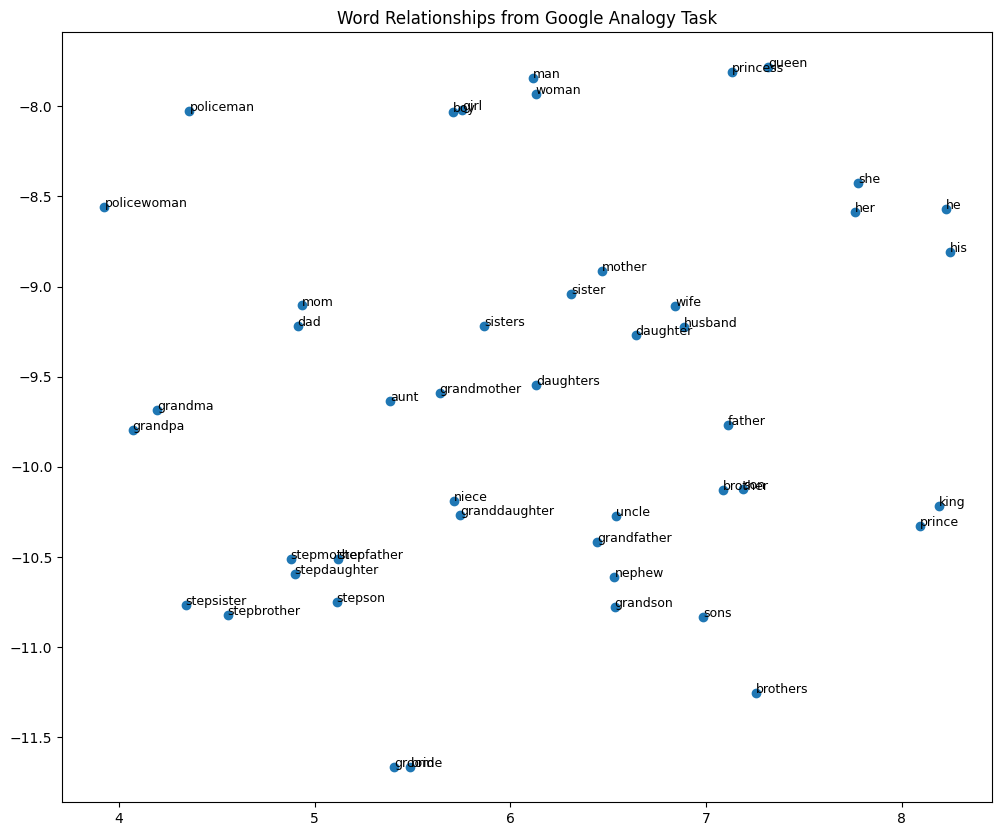

<Figure size 640x480 with 0 Axes>

In [13]:
# 11. TODO3: 使用 t-SNE 畫出 SUB_CATEGORY `: family` 的詞在 2D 空間的分佈

# Collect words from Google Analogy dataset
SUB_CATEGORY = ": family"

# 篩出 family 類別的資料
family_df = df[df["SubCategory"] == SUB_CATEGORY]

# 收集這個 sub-category 裡所有出現過的單字
words = set()
for question in family_df["Question"]:
    word_a, word_b, word_c, word_d = question.lower().split()
    words.update([word_a, word_b, word_c, word_d])

# 只保留在 model vocabulary 裡的字
valid_words = []
word_embeddings = []

for word in words:
    if word in model.key_to_index:
        valid_words.append(word)
        word_embeddings.append(model[word])

word_embeddings = np.array(word_embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
word_embeddings_2d = tsne.fit_transform(word_embeddings)

# Plotting the words in 2D space
plt.figure(figsize=(12, 10))
plt.scatter(word_embeddings_2d[:, 0], word_embeddings_2d[:, 1])

# Annotate points with words
for i, word in enumerate(valid_words):
    plt.annotate(
        word, (word_embeddings_2d[i, 0], word_embeddings_2d[i, 1]), fontsize=9
    )

plt.title("Word Relationships from Google Analogy Task")
plt.show()
plt.savefig("word_relationships.png", bbox_inches="tight")

### Part III: Train your own word embeddings

### Get the latest English Wikipedia articles and do sampling.
- Usually, we start from Wikipedia dump (https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-pages-articles.xml.bz2). However, the downloading step will take very long. Also, the cleaning step for the Wikipedia corpus ([`gensim.corpora.wikicorpus.WikiCorpus`](https://radimrehurek.com/gensim/corpora/wikicorpus.html#gensim.corpora.wikicorpus.WikiCorpus)) will take much time. Therefore, we provide cleaned files for you.

In [14]:
# 12-1. Download the split Wikipedia files
# Each file contain 562365 lines (articles).
!gdown --id 1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd -O wiki_texts_part_0.txt.gz
!gdown --id 1ABblLRd9HXdXvaNv8H9fFq984bhnowoG -O wiki_texts_part_1.txt.gz
!gdown --id 1z2VFNhpPvCejTP5zyejzKj5YjI_Bn42M -O wiki_texts_part_2.txt.gz
!gdown --id 1VKjded9BxADRhIoCzXy_W8uzVOTWIf0g -O wiki_texts_part_3.txt.gz
!gdown --id 16mBeG26m9LzHXdPe8UrijUIc6sHxhknz -O wiki_texts_part_4.txt.gz

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd
From (redirected): https://drive.google.com/uc?id=1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd&confirm=t&uuid=fbdb563f-efc5-4642-abb8-bf86f9a1e990
To: /content/wiki_texts_part_0.txt.gz
100% 1.51G/1.51G [00:19<00:00, 77.2MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ABblLRd9HXdXvaNv8H9fFq984bhnowoG
From (redirected): https://drive.google.com/uc?id=1ABblLRd9HXdXvaNv8H9fFq984bhnowoG&confirm=t&uuid=7ca10e1a-5a25-4651-8eeb-59259885daae
To: /content/

In [15]:
# 12-2. Download the split Wikipedia files
# Each file contain 562365 lines (articles), except the last file.
!gdown --id 17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI -O wiki_texts_part_5.txt.gz
!gdown --id 19IvB2vOJRGlrYulnTXlZECR8zT5v550P -O wiki_texts_part_6.txt.gz
!gdown --id 1sjwO8A2SDOKruv6-8NEq7pEIuQ50ygVV -O wiki_texts_part_7.txt.gz
!gdown --id 1s7xKWJmyk98Jbq6Fi1scrHy7fr_ellUX -O wiki_texts_part_8.txt.gz
!gdown --id 17eQXcrvY1cfpKelLbP2BhQKrljnFNykr -O wiki_texts_part_9.txt.gz
!gdown --id 1J5TAN6bNBiSgTIYiPwzmABvGhAF58h62 -O wiki_texts_part_10.txt.gz

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI
From (redirected): https://drive.google.com/uc?id=17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI&confirm=t&uuid=73485380-24a7-4068-95c8-0ce12a98afa8
To: /content/wiki_texts_part_5.txt.gz
100% 578M/578M [00:06<00:00, 86.1MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19IvB2vOJRGlrYulnTXlZECR8zT5v550P
From (redirected): https://drive.google.com/uc?id=19IvB2vOJRGlrYulnTXlZECR8zT5v550P&confirm=t&uuid=8fb6eb9f-a054-44b6-aac8-870b5f257476
To: /content/wi

In [16]:
# 13. Extract the downloaded wiki_texts_parts files.
!gunzip -k wiki_texts_part_*.gz

In [17]:
# 14. Combine the extracted wiki_texts_parts files.
!cat wiki_texts_part_*.txt > wiki_texts_combined.txt

In [18]:
# 15. Check the first ten lines of the combined file
!head -n 10 wiki_texts_combined.txt

anarchism is political philosophy and movement that is against all forms of authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy typically including the state and capitalism anarchism advocates for the replacement of the state with stateless societies and voluntary free associations as historically left wing movement this reading of anarchism is placed on the farthest left of the political spectrum usually described as the libertarian wing of the socialist movement libertarian socialism although traces of anarchist ideas are found all throughout history modern anarchism emerged from the enlightenment during the latter half of the th and the first decades of the th century the anarchist movement flourished in most parts of the world and had significant role in workers struggles for emancipation various anarchist schools of thought formed during this period anarchists have taken part in several revolutions most notably in the paris commune

Please note that we used the default parameters of [`gensim.corpora.wikicorpus.WikiCorpus`](https://radimrehurek.com/gensim/corpora/wikicorpus.html#gensim.corpora.wikicorpus.WikiCorpus) for cleaning the Wiki raw file. Thus, words with one character were discarded.

In [19]:
# 16. # TODO4: Sample `20%` Wikipedia articles
# Now you need to do sampling because the corpus is too big.
# You can further perform analysis with a greater sampling ratio.

import random
random.seed(42)
wiki_txt_path = "wiki_texts_combined.txt"
output_path = "wiki_texts_sampled.txt"
# wiki_texts_combined.txt is a text file separated by linebreaks (\n).
# Each row in wiki_texts_combined.txt indicates a Wikipedia article.

# yield逐行產生
def sample_wiki_articles(file_path, ratio=0.4):
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if random.random() < ratio:
                yield line
#with open(wiki_txt_path, "r", encoding="utf-8") as f:
with open(output_path, "w", encoding="utf-8") as output_file:
  # Write your code here
    for article in sample_wiki_articles(wiki_txt_path, 0.4):
        output_file.write(article)

In [20]:
# 17. TODO5: Train your own word embeddings with the sampled articles
# https://radimrehurek.com/gensim/models/word2vec.html#gensim.models.word2vec.Word2Vec
# Hint: You should perform some pre-processing before training.
from gensim.models.callbacks import CallbackAny2Vec
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from tqdm import tqdm
class WikiSentences:
    def __init__(self, path):
        self.path = path

    def __iter__(self):
        with open(self.path, "r", encoding="utf-8") as f:
            for line in tqdm(f):
                tokens = simple_preprocess(line)
                if tokens:
                    yield tokens

sentences = WikiSentences("wiki_texts_sampled.txt")


# train model
model_custom = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=2,                 # 只跑 2 個 epoch
)

2249543it [48:48, 768.11it/s] 
2249543it [1:36:55, 386.80it/s]
2249543it [1:36:40, 387.82it/s]


In [21]:
# 18. 再次讀入資料（方便同學單獨進行 Part 3）

data = pd.read_csv("questions-words.csv")

In [ ]:
# 19. TODO6: Do predictions and preserve the gold answers (word_D)
preds = []
golds = []

for analogy in tqdm(data["Question"]):
    # Use your trained word embeddings for getting predictions of the analogy task.
    # You should also preserve the gold answers during iterations for evaluations later.
    """ Hints
    # Unpack the analogy (e.g., "man", "woman", "king", "queen")
    # Perform vector arithmetic: word_b + word_c - word_a should be close to word_d
    # Source: https://github.com/piskvorky/gensim/blob/develop/gensim/models/keyedvectors.py#L778
    # Mikolov et al., 2013: big - biggest and small - smallest
    # Mikolov et al., 2013: X = vector(”biggest”) − vector(”big”) + vector(”small”).
    """
    # Write your code here
    word_a, word_b, word_c, word_d = analogy.lower().split()

    # 保留 gold的答案
    golds.append(word_d)

    try:
        # 向量運算
        resu = model_custom.wv.most_similar(
            positive=[word_b, word_c],
            negative=[word_a],
            topn=1
        )
        preds.append(resu[0][0])
    except KeyError:
        # 若詞不在詞彙表中，填入空字串
        preds.append("")

100%|██████████| 19544/19544 [31:23<00:00, 10.38it/s]


In [23]:
# 算自己訓練的model的準確率
# 10. 進行模型評估，此格不需要修改

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: semantic, Accuracy: 65.52035178712369%
Category: syntactic, Accuracy: 51.297423887587826%
Sub-Category: capital-common-countries, Accuracy: 81.81818181818183%
Sub-Category: capital-world, Accuracy: 79.39876215738285%
Sub-Category: currency, Accuracy: 14.087759815242496%
Sub-Category: city-in-state, Accuracy: 50.34454803404945%
Sub-Category: family, Accuracy: 87.15415019762845%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 21.572580645161292%
Sub-Category: gram2-opposite, Accuracy: 17.24137931034483%
Sub-Category: gram3-comparative, Accuracy: 67.26726726726727%
Sub-Category: gram4-superlative, Accuracy: 39.839572192513366%
Sub-Category: gram5-present-participle, Accuracy: 45.359848484848484%
Sub-Category: gram6-nationality-adjective, Accuracy: 85.05315822388994%
Sub-Category: gram7-past-tense, Accuracy: 48.65384615384615%
Sub-Category: gram8-plural, Accuracy: 55.63063063063063%
Sub-Category: gram9-plural-verbs, Accuracy: 50.57471264367817%


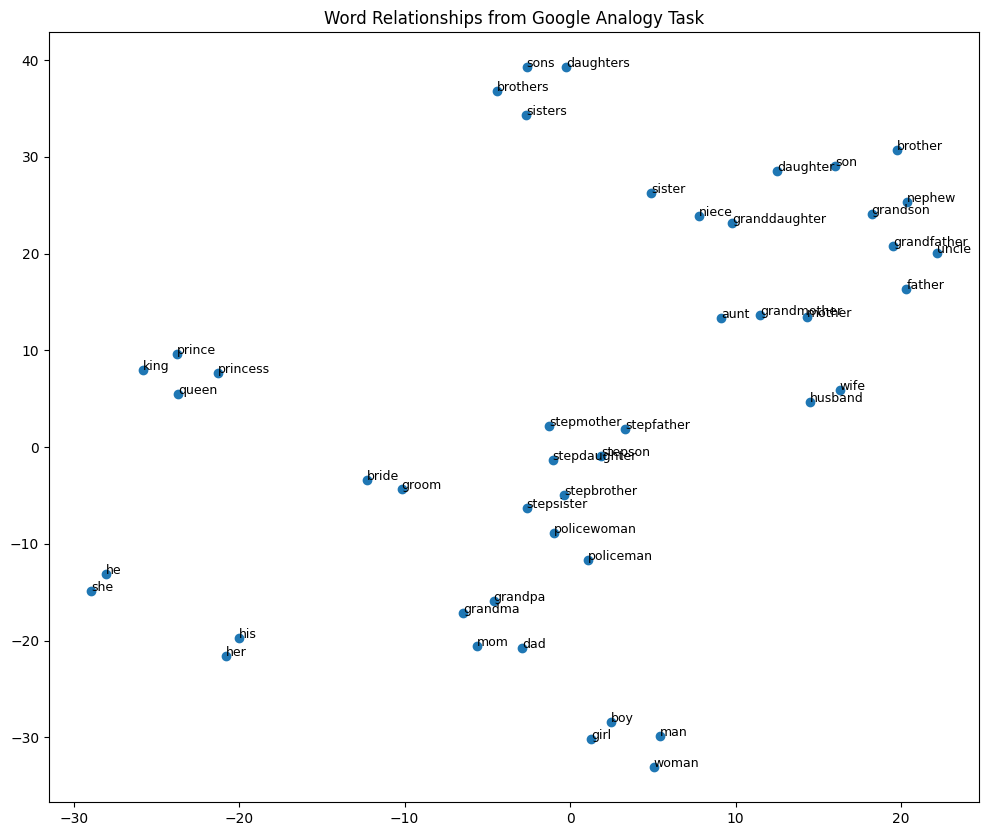

<Figure size 640x480 with 0 Axes>

In [24]:
# 20. TODO7: 使用 t-SNE 畫出 SUB_CATEGORY `: family` 的詞在 2D 空間的分佈

# Collect words from Google Analogy dataset
SUB_CATEGORY = ": family"

family_df = df[df["SubCategory"] == SUB_CATEGORY]

words = set()
for question in family_df["Question"]:
    word_a, word_b, word_c, word_d = question.lower().split()
    words.update([word_a, word_b, word_c, word_d])

valid_words = []
word_embeddings = []

for word in words:
    try:
        word_embeddings.append(model_custom.wv[word])
        valid_words.append(word)
    except KeyError:
        pass

import numpy as np
word_embeddings = np.array(word_embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
word_embeddings_2d = tsne.fit_transform(word_embeddings)

# Plotting the words in 2D space
plt.figure(figsize=(12, 10))
plt.scatter(word_embeddings_2d[:, 0], word_embeddings_2d[:, 1])

# Annotate points with words
for i, word in enumerate(valid_words):
    plt.annotate(
        word, (word_embeddings_2d[i, 0], word_embeddings_2d[i, 1]), fontsize=9
    )
plt.title("Word Relationships from Google Analogy Task")
plt.show()
plt.savefig("word_relationships.png", bbox_inches="tight")